# RNN으로_금융앱리뷰_분석하기

In [17]:
!pip install numpy

In [ ]:
from konlpy.tag import Mecab
mecab = Mecab()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, Embedding
from tensorflow.keras.utils import to_categorical

In [2]:
train_data = pd.read_csv('../05machine_learning/data/bank_app_reviews_train.csv')
train_data.head()

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!,NaN,하나
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스
4,2023-11-13,1,알뜰폰 인증이 안돼요.....,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리


특수문자 제거 함수
- 벡터화 하려면 특수문자 없어야함

In [3]:
import re

def clean_text(text):
    cleaned = re.sub(r'[^가-힣a-zA-Z0-9\s]','',text)  # 한글 영문 숫자 추출
    cleaned = re.sub(r'\s+',' ', cleaned) # 연속된 공백을 하나의 공백으로 줄임
    return cleaned.strip()

사용자 리뷰에서 특수문자 제거

In [4]:
train_data['사용자리뷰'] = train_data['사용자리뷰'].apply(clean_text)
train_data

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음,NaN,하나
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스
4,2023-11-13,1,알뜰폰 인증이 안돼요,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리
...,...,...,...,...,...
22241,2025-03-12,3,어플 시작오류가 가끔 나네요,안녕하세요 푸딩 고객님. 우리은행 우리WON뱅킹 이용에 불편을 드려 죄송합니다. 2...,우리
22242,2025-01-09,1,업데이트 후에 계좌이체하는 게 자주 튕겨요,안녕하세요 일월구일 고객님. 먼저 우리WON뱅킹 이용에 불편을 드려 죄송합니다. 보...,우리
22243,2023-07-07,5,굳굳굳,"Seung Woo Kim 고객님, 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로...",국민
22244,2024-10-10,5,오래시간 같이한 나의은행 든든합니다,안녕하세요 lee jeong seon (isate) 고객님. 칭찬 진심으로 감사드리...,우리


is_good 컬럼 추가, 평점 4이상은 긍정: 1, 3이하는 부정: 0

In [5]:
train_data['is_good'] = train_data['평점'].apply(lambda x: 1 if x >= 4 else 0)
train_data['is_good']

0        1
1        0
2        1
3        0
4        0
        ..
22241    0
22242    0
22243    1
22244    1
22245    0
Name: is_good, Length: 22246, dtype: int64

토큰화

In [6]:
mecab = Mecab()
mecab.morphs(train_data['사용자리뷰'][0])  # 형태로 단위로 분리

['엄',
 '빠',
 '폰',
 '에',
 '설치',
 '해',
 '드렸',
 '는데',
 '두',
 '분',
 '다',
 '쓰',
 '기',
 '편하',
 '다고',
 '하',
 '시',
 '네요',
 '저',
 '도',
 '쓰',
 '고',
 '있',
 '음']

전체 문장을 토큰화 한 후 tokenized_docs에 저장

In [7]:
tokenized_docs = train_data['사용자리뷰'].apply(mecab.morphs)

In [8]:
tokenized_docs[2]

['서비스',
 '가',
 '통합',
 '되',
 '어',
 '있',
 '어서',
 '점점',
 '사용',
 '빈도',
 '가',
 '높',
 '아',
 '지',
 '네요']

단어 인덱스 생성

In [9]:
token = Tokenizer(lower=False)
token.fit_on_texts(tokenized_docs)
print(len(token.word_index))

13010


문장 벡터화

In [10]:
x = token.texts_to_sequences(tokenized_docs)
print(x[0])

[5400, 1682, 170, 11, 159, 37, 2292, 14, 301, 184, 28, 45, 19, 106, 123, 1, 76, 15, 216, 5, 45, 2, 10, 64]


가장 긴 문장의 길이 구하기

In [11]:
max_length = max([len(i) for i in x]) + 1

가장 긴 길이에 맞춰서 패딩
* RNN의 경우 패딩을 post로 주는 것이 더 좋음, 단어가 앞, 0이 뒤에 붙음
* Transformer 계열은 위치 정보가 따로 있으므로 post, pre든 차이가 없음

In [12]:
X_padded = pad_sequences(x, maxlen=max_length, padding = 'post')
print(X_padded[0])

[5400 1682  170   11  159   37 2292   14  301  184   28   45   19  106
  123    1   76   15  216    5   45    2   10   64    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [13]:
X_padded.shape

(22246, 302)

In [14]:
y = train_data['is_good']
y.value_counts()

is_good
1    13240
0     9006
Name: count, dtype: int64

홀드아웃

In [15]:
!pip install scikit-learn

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_valid, y_train, y_valid= train_test_split(X_padded, y, test_size=0.3, stratify=y, random_state=42)

In [18]:
# 임베딩에 입력할 단어 수 추출
word_size = len(token.word_index)+1
print(word_size)

13011


# 양방향 RNN 네트워크를 이용해 텍스트 분석

In [19]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [20]:
birnn = Sequential()
birnn.add(Input(shape=(max_length, )))
birnn.add(Embedding(input_dim=word_size, output_dim=64))
birnn.add(Bidirectional(SimpleRNN(128, return_sequences=False, activation='tanh')))
birnn.add(Dense(32,activation='relu'))
birnn.add(Dropout(0.5))
birnn.add(Dense(1,activation='sigmoid'))
birnn.summary()

E0000 00:00:1747815139.378539    5656 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1747815139.399357    5656 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 302, 64)        │       832,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,369 (3.40 MB)

 Trainable params: 890,369 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7633 - auc: 0.8006 - loss: 0.5331
Epoch 1: val_loss improved from inf to 0.29889, saving model to ./model/bank_app_review_birnn.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 424ms/step - accuracy: 0.7641 - auc: 0.8018 - loss: 0.5317 - val_accuracy: 0.8828 - val_auc: 0.9429 - val_loss: 0.2989
Epoch 2/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8975 - auc: 0.9446 - loss: 0.2847
Epoch 2: val_loss improved from 0.29889 to 0.27667, saving model to ./model/bank_app_review_birnn.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 492ms/step - accuracy: 0.8975 - auc: 0.9446 - loss: 0.2846 - val_accuracy: 0.8932 - val_auc: 0.9504 - val_loss: 0.2767
Epoch 3/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9249 - auc: 0.9627 - loss: 0.2260
Epoch 3: val_loss did not improve from 0.27667
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.9249 - auc: 0.9627 - loss: 0.2258 - val_accuracy: 0.8962 - val_auc: 0.9489 - val_loss: 

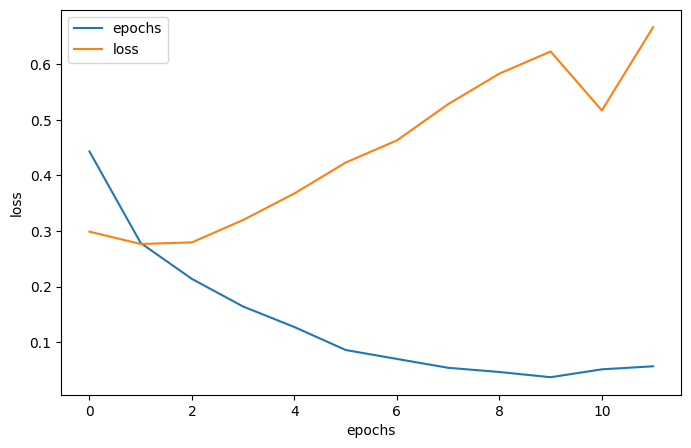

In [22]:
birnn.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_birnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                             save_best_only = True,
                             verbose = 1)
birnn_history = birnn.fit(X_train, y_train, epochs=1000, batch_size=256,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8,5))
plt.plot(birnn_history.history['loss'])
plt.plot(birnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['epochs','loss'])
plt.show()
                             

In [25]:
print(birnn.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9000 - auc: 0.9534 - loss: 0.2697
[0.2766678035259247, 0.8931674957275391, 0.9503904581069946]


In [41]:
pred = birnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step


array([[0.9883942 ],
       [0.8539183 ],
       [0.08924966],
       ...,
       [0.94700044],
       [0.13540512],
       [0.9621383 ]], dtype=float32)

In [29]:
y_valid

10299    1
11621    1
3616     0
3994     1
7488     0
        ..
10152    0
10710    1
5641     1
10113    0
14478    1
Name: is_good, Length: 6674, dtype: int64

In [42]:
pred = pd.DataFrame(pred)

In [43]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))

In [44]:
result = pd.concat([y_valid, pred], axis=1)
result.columns = ['is_good','pred']

In [45]:
result['pred'] = result['pred'].apply(lambda x: 1 if x>0.5 else 0)
result

,is_good,pred
0,1,1
1,1,1
2,0,0
3,1,1
4,0,0
...,...,...
6669,0,0
6670,1,1
6671,1,1
6672,0,0


In [46]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      2702
           1       0.91      0.91      0.91      3972

    accuracy                           0.89      6674
   macro avg       0.89      0.89      0.89      6674
weighted avg       0.89      0.89      0.89      6674



# LSTM과 CNN 조합 모델로 분석

In [47]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, GlobalMaxPooling1D

In [50]:
lstm_cnn = Sequential()

# CNN
lstm_cnn.add(Input(shape=(max_length, )))
lstm_cnn.add(Embedding(input_dim=word_size, output_dim=128))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))

# LSTM
lstm_cnn.add(Bidirectional(LSTM(256, return_sequences=True)))

# DNN
lstm_cnn.add(GlobalMaxPooling1D())
lstm_cnn.add(Dense(64, activation='relu'))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Dense(32, activation='relu'))
lstm_cnn.add(Dense(1, activation='sigmoid'))
lstm_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 302, 128)       │     1,665,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 302, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 298, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 70, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 17, 512)        │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,652,929 (10.12 MB)

 Trainable params: 2,652,929 (10.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.7397 - auc: 0.7912 - loss: 0.5177
Epoch 1: val_loss improved from inf to 0.29530, saving model to ./model/bank_app_review_lstm_cnn.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 49s 364ms/step - accuracy: 0.7403 - auc: 0.7920 - loss: 0.5168 - val_accuracy: 0.8846 - val_auc: 0.9463 - val_loss: 0.2953
Epoch 2/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9079 - auc: 0.9552 - loss: 0.2544
Epoch 2: val_loss improved from 0.29530 to 0.25997, saving model to ./model/bank_app_review_lstm_cnn.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 44s 362ms/step - accuracy: 0.9079 - auc: 0.9552 - loss: 0.2544 - val_accuracy: 0.8972 - val_auc: 0.9545 - val_loss: 0.2600
Epoch 3/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9331 - auc: 0.9740 - loss: 0.1889
Epoch 3: val_loss did not improve from 0.25997
122/122 ━━━━━━━━━━━━━━━━━━━━ 45s 368ms/step - accuracy: 0.9331 - auc: 0.9740 - loss: 0.1889 - val_accuracy: 0.8930 - val_auc: 0

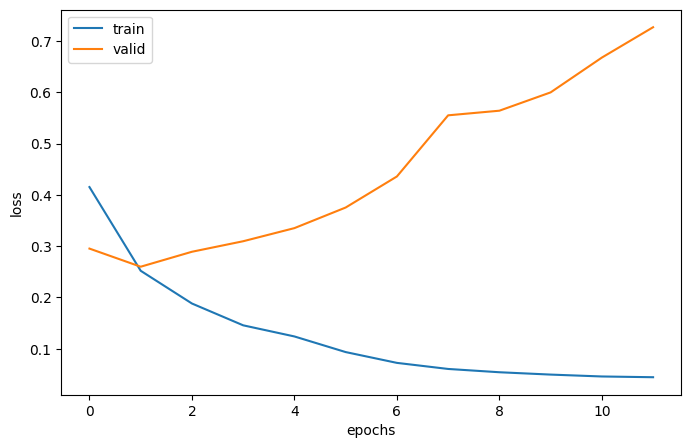

In [52]:
lstm_cnn.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_lstm_cnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                             save_best_only = True,
                             verbose = 1)
lstm_cnn_history = lstm_cnn.fit(X_train, y_train, epochs=1000, batch_size=128,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8,5))
plt.plot(lstm_cnn_history.history['loss'])
plt.plot(lstm_cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.show()